<a href="https://colab.research.google.com/github/jhayushi/Parkinson-s-Model/blob/main/Ayushi_RandomForest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Model for Parkinson's Disease Detection. This notebook trains and evaluates a Random Forest classifier using the Parkinson's voice dataset. The goal is to classify whether a voice recording belongs to a healthy individual or a patient with Parkinson's disease.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Mounted at /content/drive


Load the dataset

In [ ]:
parkinsons_data = pd.read_csv(
    "./drive/Shareddrives/AI4ALL Group O1C/parkinsons/parkinsons.data"
)

In [ ]:
## Exploratory Data Analysis (EDA)
parkinsons_data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
print("Dataset Shape:", parkinsons_data.shape)

Dataset Shape: (195, 24)


In [ ]:
parkinsons_data.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [ ]:
parkinsons_data.dtypes

,0
name,object
MDVP:Fo(Hz),float64
MDVP:Fhi(Hz),float64
MDVP:Flo(Hz),float64
MDVP:Jitter(%),float64
MDVP:Jitter(Abs),float64
MDVP:RAP,float64
MDVP:PPQ,float64
Jitter:DDP,float64
MDVP:Shimmer,float64


In [ ]:
parkinsons_data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
parkinsons_data["status"].value_counts()

,count
status,
1,147
0,48


In [ ]:
## Prepare Features and Target
X = parkinsons_data.drop(columns=["name","status"])
y = parkinsons_data["status"]

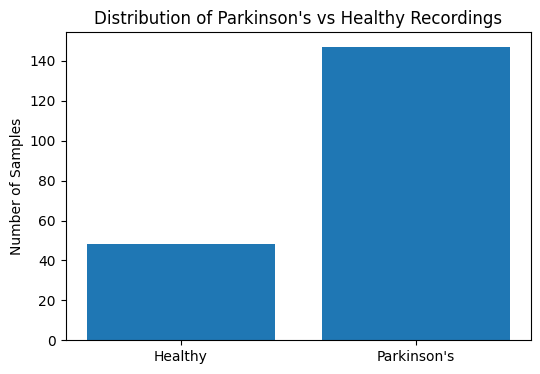

In [ ]:
counts = parkinsons_data["status"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["Healthy","Parkinson's"],
    [counts[0], counts[1]]
)

plt.title("Distribution of Parkinson's vs Healthy Recordings")
plt.ylabel("Number of Samples")

plt.show()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
y.head()

,status
0,1
1,1
2,1
3,1
4,1


In [ ]:
## Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
## Train the Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9230769230769231


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



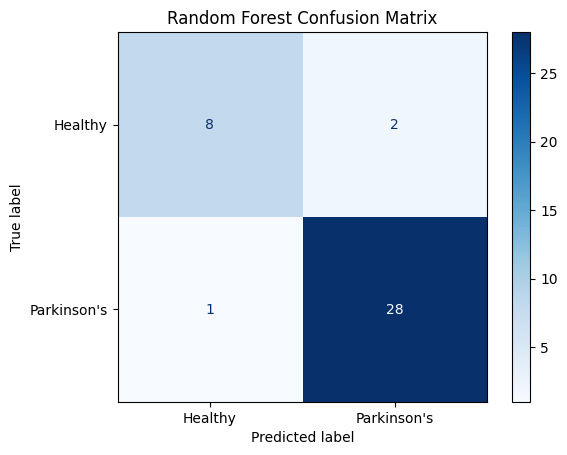

In [ ]:
## Confusion Matrix
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy","Parkinson's"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

## Medical Error Analysis

The confusion matrix allows us to examine different types of classification errors.
In medical applications, false positives and false negatives have different implications.

False positives occur when healthy individuals are incorrectly classified as having Parkinson's disease.

False negatives occur when Parkinson's patients are incorrectly classified as healthy. These errors are especially important because missed detection may delay further evaluation.

In [ ]:
## Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
21,PPE,0.152476
18,spread1,0.106974
0,MDVP:Fo(Hz),0.064174
14,NHR,0.062347
7,Jitter:DDP,0.056404
1,MDVP:Fhi(Hz),0.055774
2,MDVP:Flo(Hz),0.053636
19,spread2,0.040810
11,Shimmer:APQ5,0.039663
5,MDVP:RAP,0.039385


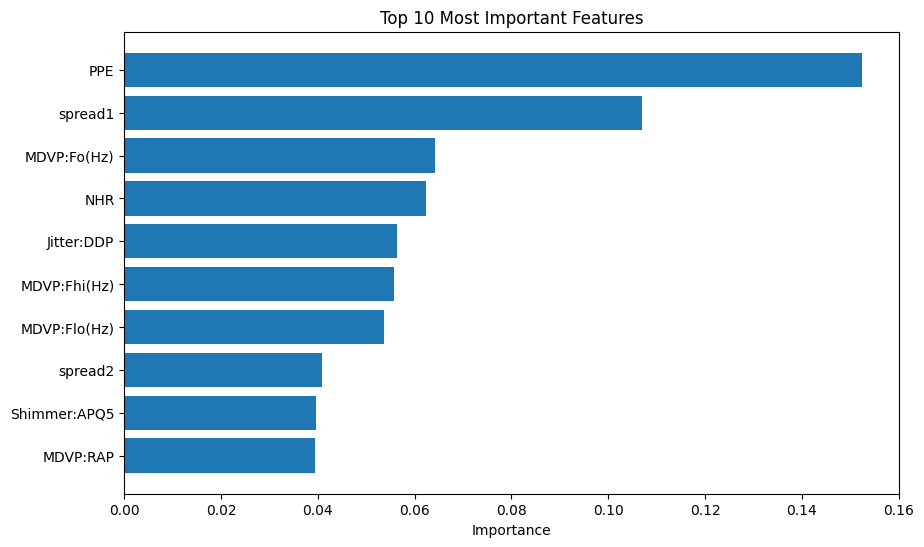

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 8
False Positives: 2
False Negatives: 1
True Positives: 28


In [ ]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = predictions

incorrect_predictions = errors[
    errors["Actual"] != errors["Predicted"]
]

incorrect_predictions

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,Actual,Predicted
185,116.286,177.291,96.983,0.00314,0.00003,0.00134,0.00192,0.00403,0.01564,0.136,...,0.00737,24.199,0.598515,0.654331,-5.592584,0.133917,2.058658,0.214346,0,1
194,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,0.190,...,0.04398,21.209,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569,0,1
7,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.134,...,0.00344,26.892,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755,1,0


Analyzing incorrect predictions helps identify difficult cases where
voice characteristics overlap between healthy individuals and Parkinson's patients.

In [ ]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9230769230769231


## Cross-Validation Performance, Since the dataset contains a limited number of patient recordings, cross-validation was used to evaluate whether the Random Forest model consistently performs across different subsets of data.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = parkinsons_data["name"]

X_patient = parkinsons_data.drop(
    ["status","name"],
    axis=1
)

y_patient = parkinsons_data["status"]


splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)


train_idx, test_idx = next(
    splitter.split(
        X_patient,
        y_patient,
        groups
    )
)

In [ ]:
X_train_patient = X_patient.iloc[train_idx]
X_test_patient = X_patient.iloc[test_idx]

y_train_patient = y_patient.iloc[train_idx]
y_test_patient = y_patient.iloc[test_idx]


patient_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

patient_model.fit(
    X_train_patient,
    y_train_patient
)


patient_predictions = patient_model.predict(
    X_test_patient
)


print(
    "Patient-level Accuracy:",
    accuracy_score(
        y_test_patient,
        patient_predictions
    )
)

Patient-level Accuracy: 0.9487179487179487


Patient-level splitting provides a more realistic estimate because
the model is tested on completely unseen individuals.

In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_score

group_cv = GroupKFold(n_splits=5)


scores = cross_val_score(
    model,
    X,
    y,
    groups=groups,
    cv=group_cv,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.8974359  0.8974359  0.97435897 0.94871795 0.94871795]
0.9333333333333333


In [ ]:
tree_values = [10,50,100,200,300]

results = []

for trees in tree_values:

    rf = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    rf.fit(X_train,y_train)

    acc = rf.score(X_test,y_test)

    results.append(acc)


for t,a in zip(tree_values,results):
    print(
        f"{t} trees: {a:.3f}"
    )

10 trees: 0.923
50 trees: 0.923
100 trees: 0.923
200 trees: 0.923
300 trees: 0.923


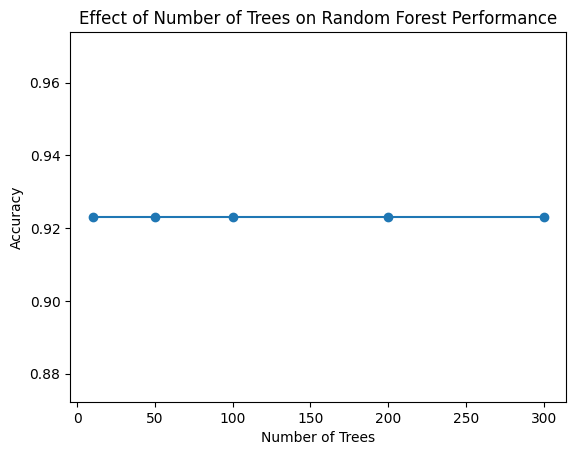

In [ ]:
plt.plot(
    tree_values,
    results,
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.title(
    "Effect of Number of Trees on Random Forest Performance"
)

plt.show()

In [ ]:
import pandas as pd

importance_results = []

for i in range(5):

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=i
    )

    rf.fit(X_train,y_train)

    importance_results.append(
        rf.feature_importances_
    )


importance_df = pd.DataFrame(
    importance_results,
    columns=X.columns
)


importance_df.mean().sort_values(
    ascending=False
).head(10)

,0
PPE,0.136584
spread1,0.107676
MDVP:Fo(Hz),0.078915
NHR,0.057184
MDVP:Fhi(Hz),0.055440
MDVP:RAP,0.050874
MDVP:APQ,0.045637
spread2,0.042654
Jitter:DDP,0.042219
MDVP:Flo(Hz),0.041666


## SHAP Explainability Analysis

## Random Forest models can achieve high accuracy but are often considered "black box" models. SHAP (SHapley Additive exPlanations) was used to identify which voice measurements contributed most to Parkinson's disease predictions.

## Features with higher SHAP values had a greater influence on the model's decision.

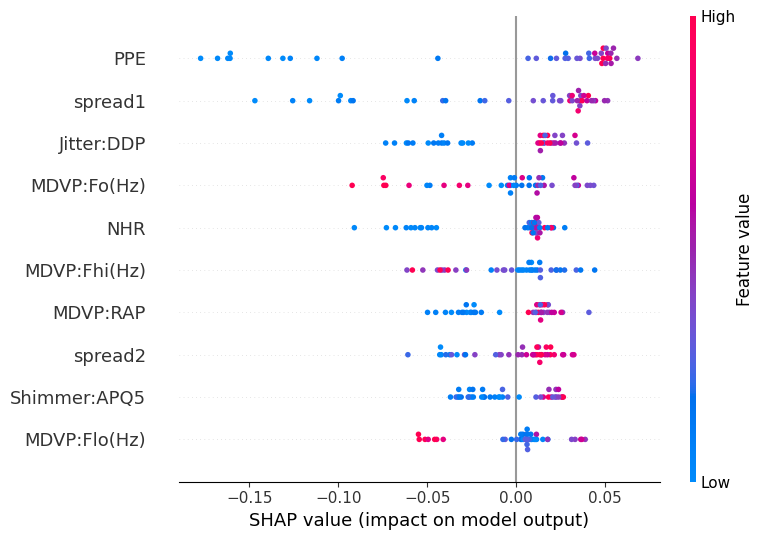

In [ ]:
import shap

# Create SHAP explainer for the trained Random Forest model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

# Visualize feature impact for Parkinson's class (class 1)
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    max_display=10
)

In [ ]:
explainer = shap.TreeExplainer(model)

## Limitations

## Although Random Forest achieved strong performance, several limitations exist:

## 1. Small dataset size:
## The dataset contains recordings from only 31 individuals.

## 2. Patient variability:
## Voice characteristics may differ based on age, gender, and recording conditions.

## 3. Prediction vs diagnosis:
## The model can identify patterns associated with Parkinson's disease but cannot replace clinical diagnosis.

## Future work could include larger datasets and additional patient information.

## Conclusion


• A Random Forest classifier was trained on the Parkinson's voice dataset.
• The model achieved approximately 92% accuracy on the test set.
• The classification report, confusion matrix, and feature importance were used to evaluate model performance.
• This serves as a baseline model for comparison with other machine learning algorithms such as SVM, XGBoost, and LightGBM.

## Future Work

Future improvements could include:
- Training on larger datasets with more diverse patient populations.
- Using patient-level validation for more realistic evaluation.
- Combining voice features with additional clinical measurements.
- Exploring other machine learning approaches such as ensemble models and deep learning.